## Boilerplate code

In [5]:
import langchain 
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate , ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()
Groq_api_key=os.getenv("GROQ_API_KEY")

llm=ChatGroq(
    api_key=Groq_api_key,
    model="openai/gpt-oss-120b",
    temperature=0.2
    )



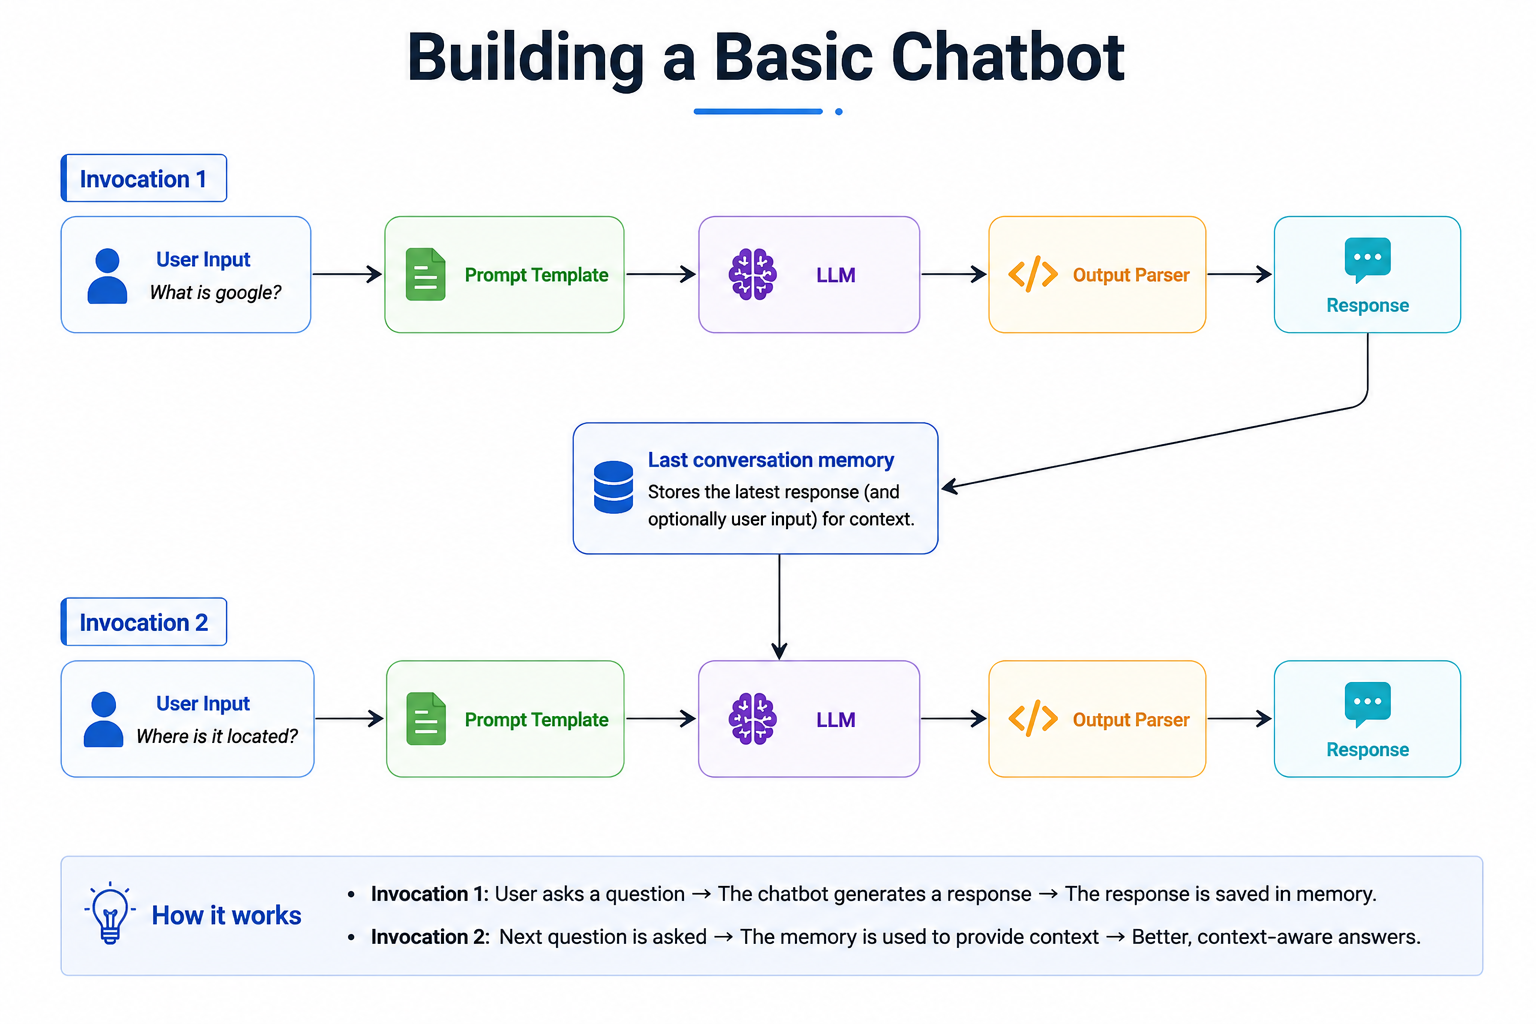

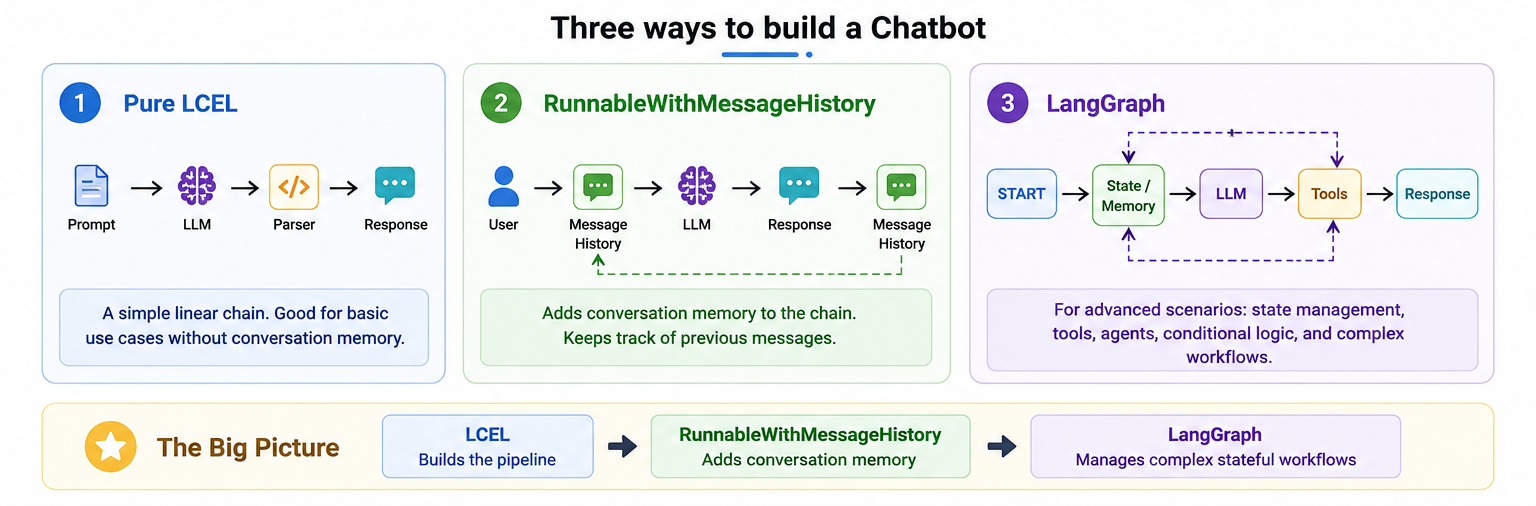

## LCEL -Single Session Method

this is happend generally , but we need to store the conversation 

In [6]:
prompt = ChatPromptTemplate.from_messages([
    ('system','You are a helpful assistant . Answer all the questions briefly and concisely .'),
    ('human','{input}')
])

chain=prompt | llm | StrOutputParser()

for storing conversation and provide memory 

In [15]:
from langchain_core.messages import HumanMessage ,AIMessage
from langchain_core.prompts import PromptTemplate , ChatPromptTemplate , MessagesPlaceholder


prompt = ChatPromptTemplate.from_messages([
    ('system','You are a helpful assistant . Answer all the questions briefly and concisely .'),
    MessagesPlaceholder('history'),
    ('human','{input}')
])

chain=prompt | llm | StrOutputParser()

conversation =[]

def chat_with_bot(payload):
    input=payload['input']
    conversation.append(HumanMessage(content=input))
    response=chain.invoke({"input":input,"history":conversation})
    conversation.append(AIMessage(content=response))
    return response

res1=chat_with_bot({'input':'Who is CEO of Google ?'})
res2=chat_with_bot({'input':'where is he from ?'})

print (res1,"\n",res2)

Sundar Pichai. 
 He was born in Madurai, Tamil Nadu, India.


### draw back in this method is only single session can perform and if incase new user came , the there is need of seperate session to store their conversation  , to overcome from this problem we go with multi session

## LCEL -Multi Session

In [ ]:
from langchain_core.messages import HumanMessage ,AIMessage
from langchain_core.prompts import PromptTemplate , ChatPromptTemplate , MessagesPlaceholder
from langchain_community.chat_message_histories import ChatMessageHistory


prompt = ChatPromptTemplate.from_messages([
    ('system','You are a helpful assistant . Answer all the questions briefly and concisely .'),
    MessagesPlaceholder('history'),
    ('human','{input}')
])

chain=prompt | llm | StrOutputParser()

conversation ={}  # {session1:[],session2:[]}

def chat_with_bot(payload):
    input=payload['input']
    session_id=payload['session_id']

    if session_id not in conversation:
        conversation[session_id]=ChatMessageHistory()

    history=conversation[session_id]

    history.add_user_message(input)
    response=chain.invoke({"input":input,"history":history.messages})
    history.add_ai_message(response)
    return response

#this is how you can use the chat_with_bot function with different session ids to maintain separate conversations
#just change the userid to maintain separate conversations for different users
res1=chat_with_bot({'input':'Who is CEO of Google ?', 'session_id':'user1'})
res2=chat_with_bot({'input':'where is he from ?', 'session_id':'user2'})

print (res1,"\n",res2)

Sundar Pichai is the CEO of Google. 
 I’m not sure who you’re referring to—could you let me know which person you mean?


## this above part is for learning purpose , how manually a chat history stores and how to work on this. apart from this we can use inBuild method to store chat history 

## RunnableWithMessageHistory

In [34]:
from langchain_core.messages import HumanMessage ,AIMessage
from langchain_core.prompts import PromptTemplate , ChatPromptTemplate , MessagesPlaceholder
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.runnables import RunnableWithMessageHistory

prompt = ChatPromptTemplate.from_messages([
    ('system','You are a helpful assistant . Answer all the questions briefly and concisely .'),
    MessagesPlaceholder('history'),
    ('human',"{input}")
])

chain=prompt | llm | StrOutputParser()

store ={}  # {session1:[],session2:[]}

def get_session_history(session_id):
    if session_id not in store:
        store[session_id]=ChatMessageHistory()
    return store[session_id]

chain_with_history=RunnableWithMessageHistory(
    chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="history"
)


#this is how you can use the chat_with_bot function with different session ids to maintain separate conversations
#just change the userid to maintain separate conversations for different users

res1=chain_with_history.invoke(
    {"input":"Who is CEO of Google ?"},
    config={"configurable":{"session_id":"user1"}}
    )

res2=chain_with_history.invoke(
    {"input":"where is he from ?"},
 config={"configurable":{"session_id":"user1"}}
 )

print (res1,"\n",res2)

C:\Users\smart\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3577: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


Sundar Pichai is the CEO of Google. 
 Sundar Pichai was born in Madurai, Tamil Nadu, India, and grew up in the nearby city of Chennai.
